# Aprendizaje Automático para la Resolución de la Cinemática Inversa en el Análisis del Movimiento Humano

---

## Estructura

1. [Instalación de dependencias](#1-instalación-de-dependencias)
2. [Carga de datos](#2-carga-de-datos)
3. [Análisis exploratorio](#3-análisis-exploratorio)
4. [Preprocesamiento](#4-preprocesamiento)
5. [Optimización de hiperparámetros SVR](#5-optimización-de-hiperparámetros-svr)
6. [Entrenamiento y evaluación](#6-entrenamiento-y-evaluación)
7. [Visualización de resultados](#7-visualización-de-resultados)
8. [Validación cruzada (XGBoost)](#8-validación-cruzada-xgboost)


#### 1. Instalación de dependencias

In [1]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor


#### 2. Carga de Datos

In [2]:
# ------------------------
# Carga y limpieza de datos
# ------------------------
 
import os
import pandas as pd
import numpy as np

def load_opensim_data(filepath):
    with open(filepath, 'r') as file:
        lines = file.readlines()

    header_end = 0
    # Encontrar la línea que marca el final del encabezado
    for i, line in enumerate(lines):
        if 'endheader' in line.strip():
            header_end = i
            break

    # Cargar los datos a partir de la línea siguiente al encabezado
    df = pd.read_csv(filepath, sep='\t', skiprows=header_end + 1)
    df.columns = [col.strip() for col in df.columns]
    return df

In [3]:
# ---------------------------------
# Rutas y mapeo de movimientos
# ---------------------------------

base_path = "."

movement_mapping = {
    'movimiento_1': 'FD',
    'movimiento_2': 'FD',
    'movimiento_3': 'FD',
    'movimiento_4': 'FD',
    'movimiento_5': 'FD',
    'movimiento_6': 'manual',
    'movimiento_7': 'manual',
    'movimiento_8': 'manual',
    'movimiento_9': 'manual'
}

dataframes = []

for carpeta, mov in movement_mapping.items():

    # Buscamos los archivos en la carpeta
    pos = os.path.join(carpeta, "posiciones.sto")
    ang = os.path.join(carpeta, "angulos.mot")

    if not os.path.exists(pos) or not os.path.exists(ang):
        continue

    df_pos = load_opensim_data(pos)
    df_ang = load_opensim_data(ang)

    # Extraemos las columnas que nos interesan
    col_x        = [c for c in df_pos.columns if 'hand_X' in c][0]
    col_y        = [c for c in df_pos.columns if 'hand_Y' in c][0]
    col_z        = [c for c in df_pos.columns if 'hand_Z' in c][0]
    col_shoulder = [c for c in df_ang.columns if 'shoulder_elev' in c and 'speed' not in c][0]
    col_elbow    = [c for c in df_ang.columns if 'elbow_flex'    in c and 'speed' not in c][0]

    inputs  = df_pos[['time', col_x, col_y, col_z]].copy()
    inputs.columns = ['time', 'hand_X', 'hand_Y', 'hand_Z']

    outputs = df_ang[['time', col_shoulder, col_elbow]].copy()
    outputs.columns = ['time', 'r_shoulder_elev', 'r_elbow_flex']

    inputs['time']  = inputs['time'].round(4)
    outputs['time'] = outputs['time'].round(4)

    df = pd.merge(inputs, outputs, on='time', how='inner')

    for col in ['hand_X', 'hand_Y', 'hand_Z', 'r_shoulder_elev', 'r_elbow_flex']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    df['movement_type'] = mov
    df['source_folder'] = carpeta
    dataframes.append(df)


df_final = pd.concat(dataframes, ignore_index=True)
print(df_final.head())

   time    hand_X    hand_Y    hand_Z  r_shoulder_elev  r_elbow_flex  \
0   0.0  0.158551  0.440371  0.144913         0.000000     70.000000   
1   0.0  0.158551  0.440371  0.144913        -0.000009     69.999996   
2   0.0  0.158551  0.440371  0.144913        -0.000032     69.999989   
3   0.0  0.158551  0.440371  0.144913         0.000000     70.000000   
4   0.0  0.158551  0.440371  0.144913        -0.000009     69.999996   

  movement_type source_folder  
0            FD  movimiento_1  
1            FD  movimiento_1  
2            FD  movimiento_1  
3            FD  movimiento_1  
4            FD  movimiento_1  


#### 3. Análisis exploratorio

In [4]:
# Dimensiones
print(f'Dimensiones del dataset: {df_final.shape}')

Dimensiones del dataset: (3623, 8)


In [5]:
print('Muestras por movimiento:')
print(df_final.groupby(['source_folder', 'movement_type']).size().to_string())

Muestras por movimiento:
source_folder  movement_type
movimiento_1   FD                742
movimiento_2   FD                287
movimiento_3   FD                537
movimiento_4   FD               1709
movimiento_5   FD                304
movimiento_6   manual             11
movimiento_7   manual             11
movimiento_8   manual             11
movimiento_9   manual             11


In [6]:
# Valores nulos
print("Valores nulos por columna:")
print(df_final.isna().sum())
print()

Valores nulos por columna:
time                0
hand_X             97
hand_Y             97
hand_Z             97
r_shoulder_elev    97
r_elbow_flex       97
movement_type       0
source_folder       0
dtype: int64



In [7]:
print('Estadísticas descriptivas:')
df_final[['hand_X','hand_Y','hand_Z','r_shoulder_elev','r_elbow_flex']].describe().round(3)

Estadísticas descriptivas:


,hand_X,hand_Y,hand_Z,r_shoulder_elev,r_elbow_flex
count,3526.000,3526.000,3526.000,3526.000,3526.000
mean,0.120,0.405,0.158,11.716,19.872
std,0.181,0.091,0.009,23.695,20.828
min,-0.206,0.321,0.144,-26.939,-50.272
25%,-0.046,0.332,0.149,-5.210,15.780
50%,0.103,0.364,0.158,2.591,20.464
75%,0.270,0.427,0.167,29.638,30.003
max,0.416,0.722,0.177,60.000,140.000


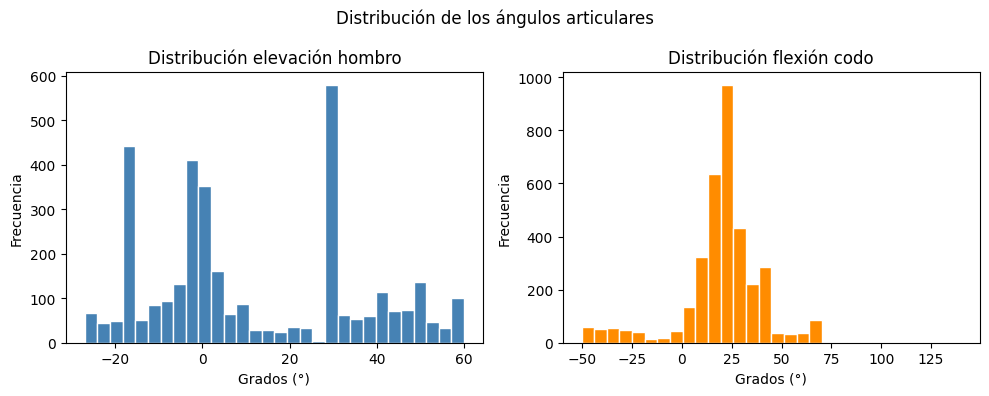

In [8]:
# Distribución de ángulos articulares
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df_final['r_shoulder_elev'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución elevación hombro')
axes[0].set_xlabel('Grados (°)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df_final['r_elbow_flex'], bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Distribución flexión codo')
axes[1].set_xlabel('Grados (°)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Distribución de los ángulos articulares', fontsize=12)
plt.tight_layout()
plt.show()

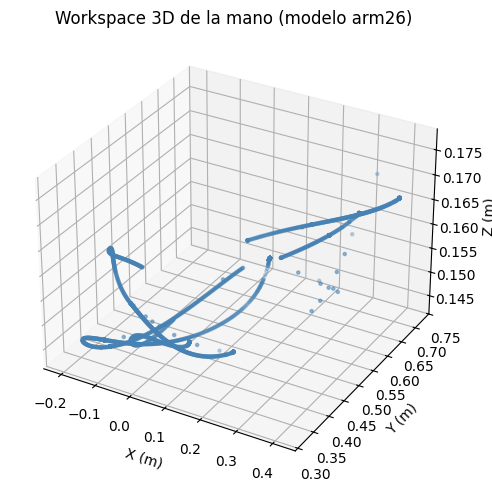

In [9]:
# Workspace 3D de la mano
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_final['hand_X'], df_final['hand_Y'], df_final['hand_Z'],
           alpha=0.3, s=5, color='steelblue')
ax.set_title('Workspace 3D de la mano (modelo arm26)')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
plt.tight_layout()
plt.show()

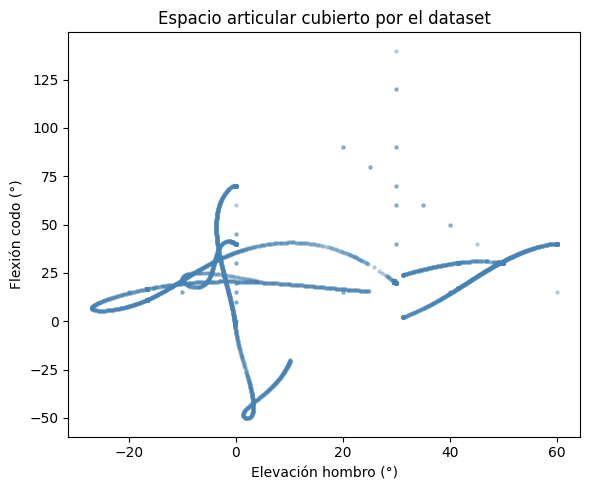

In [10]:
# Espacio articular cubierto
plt.figure(figsize=(6, 5))
plt.scatter(df_final['r_shoulder_elev'], df_final['r_elbow_flex'],
            alpha=0.3, s=5, color='steelblue')
plt.xlabel('Elevación hombro (°)')
plt.ylabel('Flexión codo (°)')
plt.title('Espacio articular cubierto por el dataset')
plt.tight_layout()
plt.show()

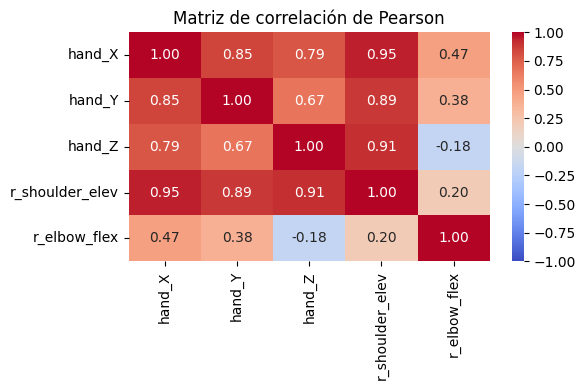

In [11]:
# Matriz de correlación de Pearson
cols = ['hand_X', 'hand_Y', 'hand_Z', 'r_shoulder_elev', 'r_elbow_flex']
corr = df_final[cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de correlación de Pearson')
plt.tight_layout()
plt.show()

### 4. Preprocesamiento

In [12]:
# Limpieza
n_inicial = len(df_final)
df_final = df_final.dropna()
df_final = df_final[
    (df_final['hand_X'].abs() < 5) &
    (df_final['hand_Y'].abs() < 5) &
    (df_final['hand_Z'].abs() < 5)
]
print(f'Muestras iniciales:  {n_inicial}')
print(f'Muestras tras limpieza: {len(df_final)}')
print(f'Eliminadas: {n_inicial - len(df_final)}')

Muestras iniciales:  3623
Muestras tras limpieza: 3518
Eliminadas: 105


In [13]:
X_cols = ['hand_X', 'hand_Y', 'hand_Z']
y_cols = ['r_shoulder_elev', 'r_elbow_flex']

X = df_final[X_cols].values
y = df_final[y_cols].values

# División train/test por muestras individuales (random_state fijo para reproducibilidad)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalización — el scaler se ajusta solo sobre train para evitar data leakage
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)
y_train = scaler_y.fit_transform(y_train)
y_test  = scaler_y.transform(y_test)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')

Train: 2814 muestras
Test:  704 muestras


#### 5. Optimización de hiperparámetros SVR

In [14]:
param_grid = {
    'estimator__C':       [0.1, 1, 10, 100],
    'estimator__gamma':   ['scale', 'auto', 0.01, 0.001],
    'estimator__epsilon': [0.01, 0.1, 0.5]
}

svr_base = MultiOutputRegressor(SVR(kernel='rbf'))

grid_search = GridSearchCV(
    svr_base,
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_C       = grid_search.best_params_['estimator__C']
best_gamma   = grid_search.best_params_['estimator__gamma']
best_epsilon = grid_search.best_params_['estimator__epsilon']

print(f'Mejores hiperparámetros: C={best_C}, gamma={best_gamma}, epsilon={best_epsilon}')
print(f'MAE CV (normalizado): {-grid_search.best_score_:.6f}')

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores hiperparámetros: C=100, gamma=scale, epsilon=0.01
MAE CV (normalizado): 0.006419


#### 6. Entrenamiento y evaluación

In [15]:
modelos = {
    'Regresión Lineal': LinearRegression(),

    'MLP': MLPRegressor(
        hidden_layer_sizes=(128, 64),
        max_iter=2000,
        early_stopping=True,
        random_state=42
    ),

    'XGBoost': XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ),

    # SVR con hiperparámetros optimizados mediante GridSearchCV
    # Resultado: C=100, gamma='scale', epsilon=0.01
    'SVR': MultiOutputRegressor(
        SVR(kernel='rbf', C=best_C, gamma=best_gamma, epsilon=best_epsilon)
    )
}

#### Resultados


In [16]:
resultados = []

for nombre, modelo in modelos.items():
    # Entrenamiento
    modelo.fit(X_train, y_train)

    # Inferencia — medimos tiempo sobre el conjunto de test completo
    inicio = time.perf_counter()
    y_pred = modelo.predict(X_test)
    fin    = time.perf_counter()
    tiempo_ms = (fin - inicio) * 1000

    # Des-escalamos para obtener resultados en grados
    y_test_real = scaler_y.inverse_transform(y_test)
    y_pred_real = scaler_y.inverse_transform(y_pred)

    mae_hombro = mean_absolute_error(y_test_real[:, 0], y_pred_real[:, 0])
    mae_codo   = mean_absolute_error(y_test_real[:, 1], y_pred_real[:, 1])
    r2_hombro  = r2_score(y_test_real[:, 0], y_pred_real[:, 0])
    r2_codo    = r2_score(y_test_real[:, 1], y_pred_real[:, 1])

    resultados.append({
        'Modelo':                 nombre,
        'MAE Hombro (°)':         round(mae_hombro, 2),
        'MAE Codo (°)':           round(mae_codo,   2),
        'MAE Medio (°)':          round((mae_hombro + mae_codo) / 2, 2),
        'R² Hombro':              round(r2_hombro, 3),
        'R² Codo':                round(r2_codo,   3),
        'Tiempo inferencia (ms)': round(tiempo_ms,  2)
    })

df_resultados = pd.DataFrame(resultados).sort_values('MAE Medio (°)')
print(f'Muestras en test: {X_test.shape[0]}')
print()
df_resultados

Muestras en test: 704



,Modelo,MAE Hombro (°),MAE Codo (°),MAE Medio (°),R² Hombro,R² Codo,Tiempo inferencia (ms)
2,XGBoost,0.09,0.19,0.14,1.000,0.999,10.76
3,SVR,0.16,0.13,0.15,1.000,1.000,12.03
1,MLP,0.12,0.23,0.17,1.000,1.000,1.32
0,Regresión Lineal,0.86,1.04,0.95,0.998,0.995,0.48


#### 7. Visualización de resultados

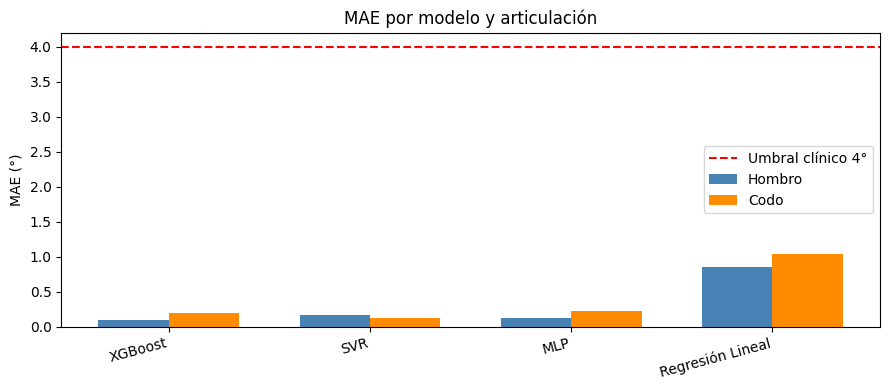

In [17]:
# Gráfica de barras — MAE por modelo y articulación
modelos_ord = df_resultados['Modelo'].tolist()
x = np.arange(len(modelos_ord))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, df_resultados.set_index('Modelo').loc[modelos_ord, 'MAE Hombro (°)'],
       w, label='Hombro', color='steelblue')
ax.bar(x + w/2, df_resultados.set_index('Modelo').loc[modelos_ord, 'MAE Codo (°)'],
       w, label='Codo', color='darkorange')
ax.axhline(4, color='red', linestyle='--', label='Umbral clínico 4°')
ax.set_title('MAE por modelo y articulación')
ax.set_ylabel('MAE (°)')
ax.set_xticks(x)
ax.set_xticklabels(modelos_ord, rotation=15, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

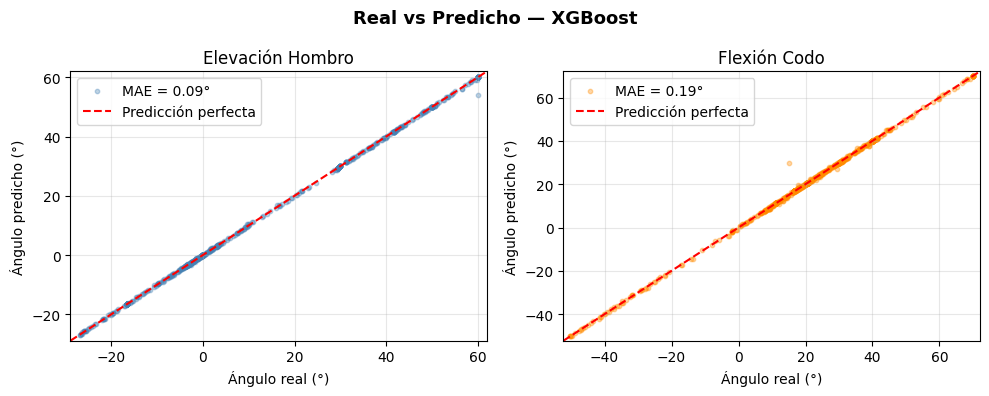

In [18]:
# Dispersión Real vs Predicho — mejor modelo (XGBoost)
mejor = df_resultados.iloc[0]['Modelo']
y_pred_mejor = modelos[mejor].predict(X_test)
y_test_real  = scaler_y.inverse_transform(y_test)
y_pred_real  = scaler_y.inverse_transform(y_pred_mejor)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colores = ['steelblue', 'darkorange']
for i, (nombre_art, color) in enumerate(zip(['Elevación Hombro', 'Flexión Codo'], colores)):
    real = y_test_real[:, i]
    pred = y_pred_real[:, i]
    mae_i = mean_absolute_error(real, pred)

    axes[i].scatter(real, pred, alpha=0.35, s=10, color=color, label=f'MAE = {mae_i:.2f}°')

    lim_min = min(real.min(), pred.min()) - 2
    lim_max = max(real.max(), pred.max()) + 2
    axes[i].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5,
                 label='Predicción perfecta')

    axes[i].set_xlim(lim_min, lim_max)
    axes[i].set_ylim(lim_min, lim_max)
    axes[i].set_xlabel('Ángulo real (°)')
    axes[i].set_ylabel('Ángulo predicho (°)')
    axes[i].set_title(nombre_art)
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle(f'Real vs Predicho — {mejor}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 8. Validación cruzada (XGBoost)

In [20]:
X_cv = df_final[X_cols].values
y_cv = df_final[y_cols].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_resultados = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_cv), start=1):
    X_tr, X_te = X_cv[train_idx], X_cv[test_idx]
    y_tr, y_te = y_cv[train_idx], y_cv[test_idx]

    sc_X = StandardScaler()
    sc_y = StandardScaler()
    X_tr = sc_X.fit_transform(X_tr)
    X_te = sc_X.transform(X_te)
    y_tr = sc_y.fit_transform(y_tr)

    modelo_cv = XGBRegressor(
        n_estimators=200, learning_rate=0.1, random_state=42
    )
    modelo_cv.fit(X_tr, y_tr)

    y_pred_cv = sc_y.inverse_transform(modelo_cv.predict(X_te))
    y_real_cv = y_te

    mae_h = mean_absolute_error(y_real_cv[:, 0], y_pred_cv[:, 0])
    mae_c = mean_absolute_error(y_real_cv[:, 1], y_pred_cv[:, 1])

    cv_resultados.append({
        'Fold':           fold,
        'MAE Hombro (°)': round(mae_h, 3),
        'MAE Codo (°)':   round(mae_c, 3),
        'MAE Medio (°)':  round((mae_h + mae_c) / 2, 3)
    })

df_cv = pd.DataFrame(cv_resultados)
print(df_cv.to_string(index=False))
print(f'\nMedia: {df_cv["MAE Medio (°)"].mean():.3f}°')
print(f'Std:   {df_cv["MAE Medio (°)"].std():.3f}°')

 Fold  MAE Hombro (°)  MAE Codo (°)  MAE Medio (°)
    1           0.087         0.185          0.136
    2           0.094         0.179          0.136
    3           0.077         0.155          0.116
    4           0.082         0.169          0.126
    5           0.125         0.190          0.158

Media: 0.134°
Std:   0.016°
